# Unit Test 01: Unified Warp Benchmark

This notebook compares four warping paths on the same image pair and displacement field:

1. `warp_v0_spatialtrans.py` on GPU as the reference standard
2. Unified SciPy warp on CPU
3. Unified PyTorch `grid_sample` warp on CPU
4. Unified PyTorch `grid_sample` warp on GPU

## Dataset used in this notebook

- **Fixed image**: `0001_1` -> `0001_1.nii.gz`
- **Moving image**: `0001_2` -> `0001_2.nii.gz`
- **Displacement field**: `dvf_f_f0001_1_m0001_2_4d_channel_last.nii.gz`

The working assumption in this notebook is that `dvf_f_f0001_1_m0001_2_4d_channel_last` is defined on the **fixed lattice** and is used to sample the **moving image** into fixed-image space.

The benchmark settings requested here are:

- interpolation: linear / bilinear (`order=1`)
- padding: constant zero (`cval=0.0`)
- PyTorch: `align_corners=True`


In [1]:
import sys
import time
from pathlib import Path
from typing import Callable, Dict, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

if "/homebase" not in sys.path:
    sys.path.append("/homebase")

from code_sync.myMedIADIRLab.data_io.image.image_base import MedicalImage
from code_sync.myMedIADIRLab.data_io.image.image_display import extract_slice, resolve_intensity_window
from code_sync.myMedIADIRLab.data_io.image.image_io import read_nifti, read_nifti_plain
from code_sync.myMedIADIRLab.data_io.warp.warp_io import read_warp_nifti, read_warp_nifti_plain
from code_sync.myMedIADIRLab.data_io.warp.warp_v0_spatialtrans import SpatialTransformer
from code_sync.myMedIADIRLab.data_io.warp.warp_v1_unified import warp_image_unified


In [2]:
PROJECT_ROOT = Path("/homebase/code_sync/myMedIADIRLab/data_io")
DATA_DIR = PROJECT_ROOT / "unittest_warp" / "data_local" / "musa"

FIXED_PATH = DATA_DIR / "0001_1.nii.gz"
MOVING_PATH = DATA_DIR / "0001_2.nii.gz"
DISP_PATH = DATA_DIR / "dvf_f_f0001_1_m0001_2_4d_channel_last.nii.gz"

fixed_image = read_nifti(FIXED_PATH)
moving_image = read_nifti(MOVING_PATH)
warp_canonical = read_warp_nifti(DISP_PATH)

fixed_np = np.asarray(fixed_image.array, dtype=np.float32)
moving_np = np.asarray(moving_image.array, dtype=np.float32)
disp_np = np.asarray(warp_canonical.array, dtype=np.float32)

### Fall back to the plain versions: not oriented
# fixed_plain_np, fixed_plain_affine = read_nifti_plain(FIXED_PATH)
# moving_plain_np, moving_plain_affine = read_nifti_plain(MOVING_PATH)
# disp_plain_np, disp_plain_affine = read_warp_nifti_plain(DISP_PATH, vector_layout="channel_last")

print(f"Fixed image path   : {FIXED_PATH}")
print(f"Moving image path  : {MOVING_PATH}")
print(f"Displacement path  : {DISP_PATH}")
print()
print("Fixed image ID  : 3455")
print("Moving image ID : 3454")
print()
print("Fixed canonical shape :", fixed_np.shape)
print("Moving canonical shape:", moving_np.shape)
print("Warp canonical shape  :", disp_np.shape)
print("Warp canonical note   : read_warp_nifti(...) now returns a MedicalWarp in canonical LPS+ channel-last format")
print()
# print("Fixed plain shape     :", fixed_plain_np.shape)
# print("Moving plain shape    :", moving_plain_np.shape)
# print("Warp plain shape      :", disp_plain_np.shape)
# print("Warp plain note       : read_warp_nifti_plain(...) returns raw on-disk array + affine with no reorientation")

assert fixed_np.shape == moving_np.shape, "Fixed and moving images must share the same spatial shape."
assert disp_np.shape == fixed_np.shape + (3,), "Expected canonical 3D displacement in channel-last format (X, Y, Z, 3)."
# assert disp_plain_np.shape == fixed_plain_np.shape + (3,), "Expected plain warp array in channel-last format after plain loading."


Fixed image path   : /homebase/code_sync/myMedIADIRLab/data_io/unittest_warp/data_local/musa/0001_1.nii.gz
Moving image path  : /homebase/code_sync/myMedIADIRLab/data_io/unittest_warp/data_local/musa/0001_2.nii.gz
Displacement path  : /homebase/code_sync/myMedIADIRLab/data_io/unittest_warp/data_local/musa/dvf_f_f0001_1_m0001_2_4d_channel_last.nii.gz

Fixed image ID  : 3455
Moving image ID : 3454

Fixed canonical shape : (160, 160, 192)
Moving canonical shape: (160, 160, 192)
Warp canonical shape  : (160, 160, 192, 3)
Warp canonical note   : read_warp_nifti(...) now returns a MedicalWarp in canonical LPS+ channel-last format



## Helper Functions

The helpers below do three things:

- convert numpy arrays to the tensor format expected by `SpatialTransformer`,
- time each method fairly, including CUDA synchronization when needed,
- report numeric differences relative to the GPU reference standard.


In [3]:
def disp_to_channel_first_3d(disp: np.ndarray, image_shape: Tuple[int, int, int]) -> np.ndarray:
    """Convert a 3D displacement field to channel-first `(3, X, Y, Z)` format."""
    if disp.shape == (3,) + image_shape:
        return disp.astype(np.float32, copy=False)
    if disp.shape == image_shape + (3,):
        return np.moveaxis(disp, -1, 0).astype(np.float32, copy=False)
    raise ValueError(f"Unsupported displacement shape {disp.shape} for image shape {image_shape}.")


def numpy_image_to_torch_volume(image: np.ndarray, device: torch.device) -> torch.Tensor:
    """Convert a 3D numpy image `(X, Y, Z)` to torch shape `(1, 1, X, Y, Z)`."""
    return torch.from_numpy(image.astype(np.float32, copy=False)).to(device=device).unsqueeze(0).unsqueeze(0)


def numpy_disp_to_torch_flow_channel_first(disp: np.ndarray, image_shape: Tuple[int, int, int], device: torch.device) -> torch.Tensor:
    """Convert a 3D numpy displacement field to torch shape `(1, 3, X, Y, Z)`."""
    disp_cf = disp_to_channel_first_3d(disp=disp, image_shape=image_shape)
    return torch.from_numpy(disp_cf).to(device=device).unsqueeze(0)


def synchronize_if_needed(device: Optional[torch.device]) -> None:
    """Synchronize CUDA timing if the device is CUDA; otherwise do nothing."""
    if device is not None and device.type == "cuda":
        torch.cuda.synchronize(device)


def time_numpy_callable(func: Callable[[], np.ndarray], repeat: int = 3, warmup: int = 1, device: Optional[torch.device] = None) -> Tuple[np.ndarray, float]:
    """Run a callable several times and return its final output and mean runtime in seconds."""
    output = None
    for _ in range(warmup):
        output = func()
        synchronize_if_needed(device)

    runtimes = []
    for _ in range(repeat):
        synchronize_if_needed(device)
        start_time = time.perf_counter()
        output = func()
        synchronize_if_needed(device)
        end_time = time.perf_counter()
        runtimes.append(end_time - start_time)

    assert output is not None
    return output, float(np.mean(runtimes))


def run_spatialtransformer_standard_gpu(moving: np.ndarray, disp: np.ndarray, gpu_index: int = 0) -> Tuple[np.ndarray, float]:
    """Run the legacy SpatialTransformer on GPU as the reference standard."""
    if not torch.cuda.is_available():
        raise RuntimeError("CUDA is not available, so the GPU reference standard cannot run.")

    device = torch.device(f"cuda:{gpu_index}")
    src = numpy_image_to_torch_volume(moving, device=device)
    flow = numpy_disp_to_torch_flow_channel_first(disp=disp, image_shape=tuple(moving.shape), device=device)
    transformer = SpatialTransformer(size=tuple(moving.shape), persistent=False).to(device)
    transformer.eval()

    @torch.no_grad()
    def _run() -> np.ndarray:
        warped = transformer(src, flow, mode="bilinear", padding_mode="zeros", align_corners=True)
        return warped.squeeze(0).squeeze(0).detach().cpu().numpy()

    return time_numpy_callable(_run, repeat=3, warmup=1, device=device)


def run_unified_scipy(moving: np.ndarray, disp: np.ndarray) -> Tuple[np.ndarray, float]:
    """Run the unified SciPy implementation on CPU."""
    def _run() -> np.ndarray:
        return warp_image_unified(
            image=moving,
            disp=disp,
            backend="scipy",
            order=1,
            padding_mode="constant",
            cval=0.0,
            debug=False,
        )

    return time_numpy_callable(_run, repeat=3, warmup=1, device=None)


def run_unified_torch_cpu(moving: np.ndarray, disp: np.ndarray) -> Tuple[np.ndarray, float]:
    """Run the unified torch implementation on CPU."""
    def _run() -> np.ndarray:
        return warp_image_unified(
            image=moving,
            disp=disp,
            backend="torch",
            order=1,
            padding_mode="constant",
            cval=0.0,
            device="cpu",
            debug=False,
        )

    return time_numpy_callable(_run, repeat=3, warmup=1, device=None)


def run_unified_torch_gpu(moving: np.ndarray, disp: np.ndarray, gpu_index: int = 0) -> Tuple[np.ndarray, float]:
    """Run the unified torch implementation on GPU."""
    if not torch.cuda.is_available():
        raise RuntimeError("CUDA is not available, so the unified GPU warp cannot run.")

    device = torch.device(f"cuda:{gpu_index}")

    def _run() -> np.ndarray:
        return warp_image_unified(
            image=moving,
            disp=disp,
            backend="torch",
            order=1,
            padding_mode="constant",
            cval=0.0,
            device=gpu_index,
            debug=False,
        )

    return time_numpy_callable(_run, repeat=3, warmup=1, device=device)


def compare_to_reference(reference: Optional[np.ndarray], candidate: np.ndarray) -> Dict[str, float]:
    """Compute simple numeric differences relative to the reference result."""
    if reference is None:
        return {
            "mae_vs_standard": np.nan,
            "rmse_vs_standard": np.nan,
            "max_abs_vs_standard": np.nan,
        }

    diff = candidate.astype(np.float32) - reference.astype(np.float32)
    return {
        "mae_vs_standard": float(np.mean(np.abs(diff))),
        "rmse_vs_standard": float(np.sqrt(np.mean(diff ** 2))),
        "max_abs_vs_standard": float(np.max(np.abs(diff))),
    }


In [4]:
GPU_INDEX = 0
results: Dict[str, np.ndarray] = {}
timings: Dict[str, float] = {}

standard_result: Optional[np.ndarray] = None

try:
    standard_result, standard_time = run_spatialtransformer_standard_gpu(moving=moving_np, disp=disp_np, gpu_index=GPU_INDEX)
    results["standard_gpu_v0"] = standard_result
    timings["standard_gpu_v0"] = standard_time
    print(f"standard_gpu_v0 finished in {standard_time:.6f} s")
except Exception as exc:
    print(f"standard_gpu_v0 skipped: {exc}")

scipy_result, scipy_time = run_unified_scipy(moving=moving_np, disp=disp_np)
results["unified_scipy_cpu"] = scipy_result
timings["unified_scipy_cpu"] = scipy_time
print(f"unified_scipy_cpu finished in {scipy_time:.6f} s")

torch_cpu_result, torch_cpu_time = run_unified_torch_cpu(moving=moving_np, disp=disp_np)
results["unified_torch_cpu"] = torch_cpu_result
timings["unified_torch_cpu"] = torch_cpu_time
print(f"unified_torch_cpu finished in {torch_cpu_time:.6f} s")

try:
    torch_gpu_result, torch_gpu_time = run_unified_torch_gpu(moving=moving_np, disp=disp_np, gpu_index=GPU_INDEX)
    results["unified_torch_gpu"] = torch_gpu_result
    timings["unified_torch_gpu"] = torch_gpu_time
    print(f"unified_torch_gpu finished in {torch_gpu_time:.6f} s")
except Exception as exc:
    print(f"unified_torch_gpu skipped: {exc}")


standard_gpu_v0 finished in 0.016728 s
unified_scipy_cpu finished in 0.596402 s
unified_torch_cpu finished in 0.271079 s
unified_torch_gpu finished in 0.018392 s


In [5]:
summary_rows = []
for method_name, warped_np in results.items():
    row = {
        "method": method_name,
        "time_seconds": timings[method_name],
        "output_shape": tuple(warped_np.shape),
        "output_dtype": str(warped_np.dtype),
    }
    row.update(compare_to_reference(reference=standard_result, candidate=warped_np))
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(by="time_seconds", ascending=True).reset_index(drop=True)
summary_df


,method,time_seconds,output_shape,output_dtype,mae_vs_standard,rmse_vs_standard,max_abs_vs_standard
0,standard_gpu_v0,0.016728,"(160, 160, 192)",float32,0.000000e+00,0.000000e+00,0.000000
1,unified_torch_gpu,0.018392,"(160, 160, 192)",float32,0.000000e+00,0.000000e+00,0.000000
2,unified_torch_cpu,0.271079,"(160, 160, 192)",float32,2.559822e-08,1.616991e-07,0.000012
3,unified_scipy_cpu,0.596402,"(160, 160, 192)",float32,1.419244e-04,5.107222e-03,0.459267


## Three-View Display

The figure below uses the shared display helpers from `image_display.py` to show
three orthogonal views for the requested rows:

- moving
- fixed
- absolute difference `|moving - fixed|`
- each deformed image in method order
- absolute difference `|deformed_i - fixed|`
- final absolute differences `|deformed_i - deformed_1|` for `i = 2, 3, 4`


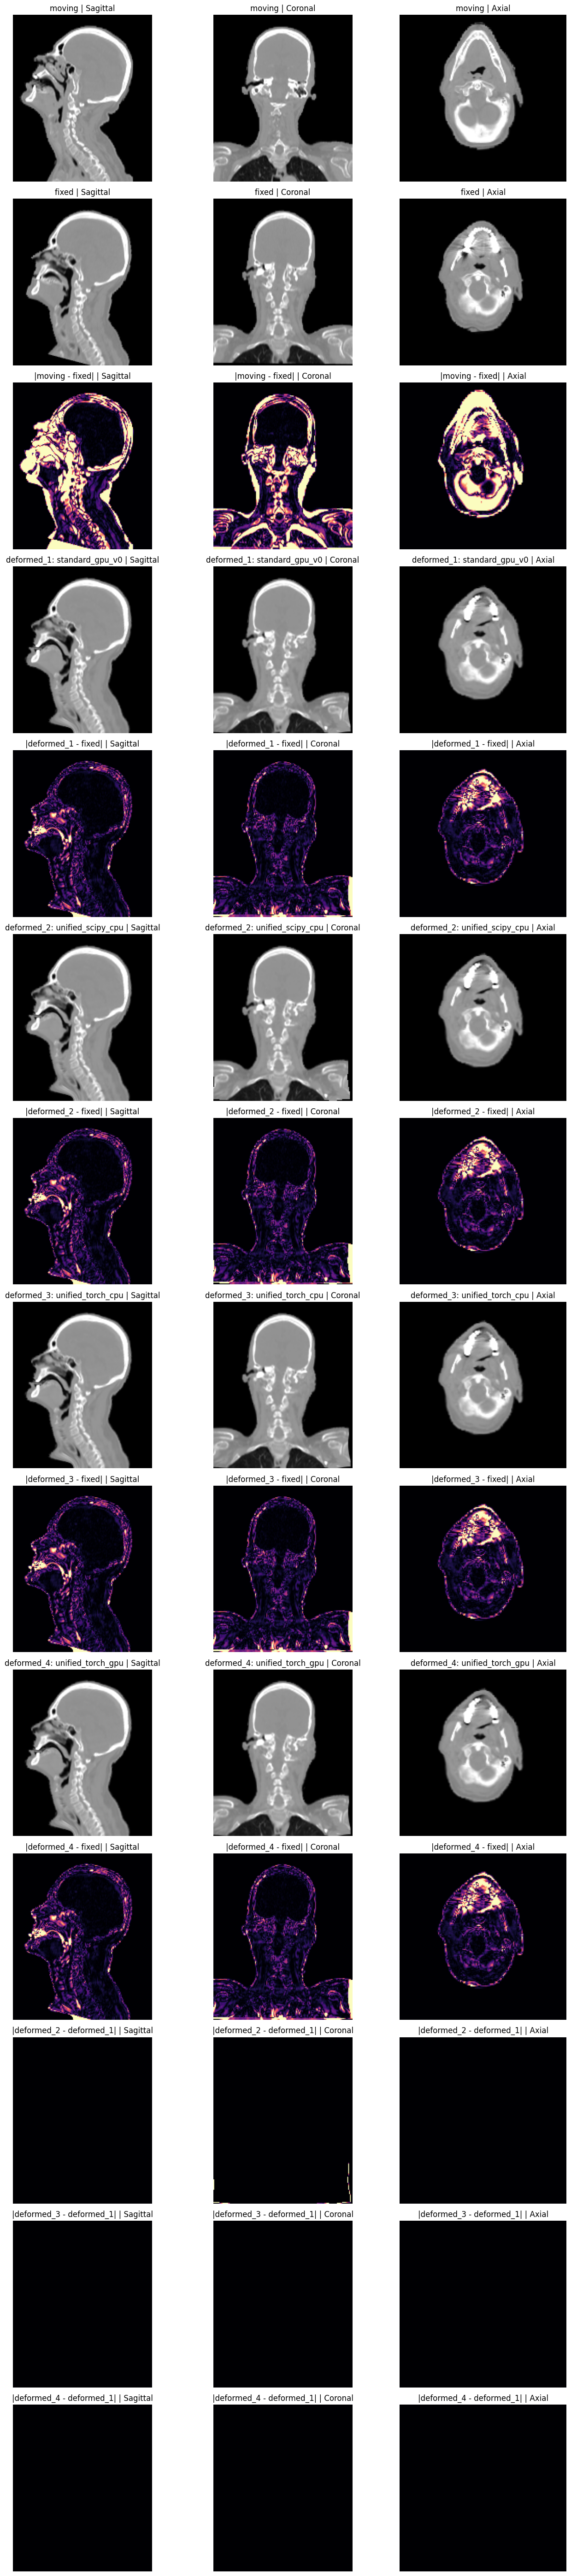

In [6]:
def make_display_image(array: np.ndarray, reference_image: MedicalImage) -> MedicalImage:
    """Wrap a 3D numpy array as a canonical MedicalImage for display helpers."""
    return MedicalImage(
        array=np.asarray(array, dtype=np.float32),
        affine_lps=reference_image.affine_lps.copy(),
        spatial_ndim=reference_image.spatial_ndim,
        axis_labels=reference_image.axis_labels,
        source_type="display",
        metadata=dict(reference_image.metadata),
    )


def render_three_view_row(
    image: MedicalImage,
    axes_row: np.ndarray,
    row_label: str,
    cmap: str,
    vmin: float | None,
    vmax: float | None,
) -> None:
    """Render sagittal, coronal, and axial views for one row."""
    for ax, view in zip(axes_row, ["sagittal", "coronal", "axial"]):
        slice_2d, info = extract_slice(image=image, view=view)
        ax.imshow(
            slice_2d,
            cmap=cmap,
            origin="lower",
            aspect=float(info["aspect"]),
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_title(f"{row_label} | {view.capitalize()}")
        ax.axis("off")


moving_display = make_display_image(moving_np, moving_image)
fixed_display = make_display_image(fixed_np, fixed_image)
moving_fixed_diff_display = make_display_image(np.abs(moving_np - fixed_np), fixed_image)

deformed_method_names = list(results.keys())
deformed_images = {
    method_name: make_display_image(results[method_name], fixed_image)
    for method_name in deformed_method_names
}
deformed_fixed_diff_images = {
    method_name: make_display_image(np.abs(results[method_name] - fixed_np), fixed_image)
    for method_name in deformed_method_names
}

deformed_1_name = deformed_method_names[0] if deformed_method_names else None
deformed_1_array = results[deformed_1_name] if deformed_1_name is not None else None

diff_vs_deformed_1_images = {}
if deformed_1_array is not None:
    for method_name in deformed_method_names[1:]:
        diff_vs_deformed_1_images[method_name] = make_display_image(
            np.abs(results[method_name] - deformed_1_array),
            fixed_image,
        )

intensity_vmin, intensity_vmax = resolve_intensity_window(
    moving_np,
    vmin_percentile=1.0,
    vmax_percentile=99.0,
)
diff_stack = [np.abs(moving_np - fixed_np)]
diff_stack.extend(np.abs(results[name] - fixed_np) for name in deformed_method_names)
if deformed_1_array is not None:
    diff_stack.extend(np.abs(results[name] - deformed_1_array) for name in deformed_method_names[1:])
all_diff_values = np.concatenate([arr.ravel() for arr in diff_stack])
diff_vmin, diff_vmax = resolve_intensity_window(
    all_diff_values,
    vmin=0.0,
    vmax_percentile=99.0,
)

row_specs = [
    ("moving", moving_display, "gray", intensity_vmin, intensity_vmax),
    ("fixed", fixed_display, "gray", intensity_vmin, intensity_vmax),
    ("|moving - fixed|", moving_fixed_diff_display, "magma", diff_vmin, diff_vmax),
]

for deformed_index, method_name in enumerate(deformed_method_names, start=1):
    row_specs.append(
        (f"deformed_{deformed_index}: {method_name}", deformed_images[method_name], "gray", intensity_vmin, intensity_vmax)
    )
    row_specs.append(
        (f"|deformed_{deformed_index} - fixed|", deformed_fixed_diff_images[method_name], "magma", diff_vmin, diff_vmax)
    )

for deformed_index, method_name in enumerate(deformed_method_names[1:], start=2):
    row_specs.append(
        (
            f"|deformed_{deformed_index} - deformed_1|",
            diff_vs_deformed_1_images[method_name],
            "magma",
            diff_vmin,
            diff_vmax,
        )
    )

fig, axes = plt.subplots(nrows=len(row_specs), ncols=3, figsize=(14, 4 * len(row_specs)))
if len(row_specs) == 1:
    axes = np.expand_dims(axes, axis=0)

for row_index, (row_label, image_obj, cmap, vmin, vmax) in enumerate(row_specs):
    render_three_view_row(
        image=image_obj,
        axes_row=axes[row_index],
        row_label=row_label,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

plt.tight_layout()
plt.show()


In [7]:
print("Quick unified debug run with canonical image and canonical warp:")
debug_result = warp_image_unified(
    image=moving_np,
    disp=disp_np,
    backend="torch",
    order=1,
    padding_mode="constant",
    cval=0.0,
    device="cpu",
    debug=True,
)
print("Debug output shape:", debug_result.shape)


Quick unified debug run with canonical image and canonical warp:
[warp_image_unified] backend: torch
[warp_image_unified] spatial_ndim: 3
[warp_image_unified] image_shape: (160, 160, 192)
[warp_image_unified] image_dtype: float32
[warp_image_unified] disp_original_shape: (160, 160, 192, 3)
[warp_image_unified] disp_original_dtype: float32
[warp_image_unified] disp_detected_layout: channel_last
[warp_image_unified] disp_channel_last_shape: (160, 160, 192, 3)
[warp_image_unified] compute_dtype: float32
[warp_image_unified] order: 1
[warp_image_unified] padding_mode: constant
[warp_image_unified] cval: 0.0
[warp_image_unified] torch_device: cpu
[warp_image_unified] torch_mode: bilinear
[warp_image_unified] torch_padding_mode: zeros
[warp_image_unified] align_corners: True
Debug output shape: (160, 160, 192)
